# Medical Appointment No Shows

## Цель проекта
Предсказать, придёт ли пациент на приём к врачу.

Это задача бинарной классификации, где:
- 1 -- пациент не пришёл
- 0 -- пациент пришёл

## Датасет
Источник: Kaggle -- Medical Appointment No Shows

- 110 527 записей
- 14 признаков
- Содерижт реальные медицинские данные

## Задачи EDA
- Первичный анализ данных
- Очистка (пропуски, дубликаты, ошибки)
- Feature engineering
- Визуализация зависимостей
- Подготовка данных для моделирования

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

## Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/KaggleV2-May-2016.csv')

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Общая информация о датасете

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
df.shape

(110527, 14)

## Проверка пропущенных значений

In [6]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

В датасете отсутствуют пропущенные значения.

## Проверка дубликатов

In [7]:
df.duplicated().sum()

np.int64(0)

### Вывод:
Проверяем наличие полных дубликатов.
При необходимости можно удалить.

In [8]:
df = df.drop_duplicates()

## Приведение типов данных

In [9]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df.dtypes

PatientId                     float64
AppointmentID                   int64
Gender                            str
ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
Age                             int64
Neighbourhood                     str
Scholarship                     int64
Hipertension                    int64
Diabetes                        int64
Alcoholism                      int64
Handcap                         int64
SMS_received                    int64
No-show                           str
dtype: object

## Очистка данных

In [10]:
# Возраст
df['Age'].describe()
df = df[df['Age'] >= 0]

In [11]:
df['Gender'].value_counts()

Gender
F    71839
M    38687
Name: count, dtype: int64

In [12]:
df['No-show'].value_counts()

No-show
No     88207
Yes    22319
Name: count, dtype: int64

## Преобразование целевой переменной

In [13]:
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})
df['No-show'].value_counts(normalize=True)

No-show
0    0.798066
1    0.201934
Name: proportion, dtype: float64

### Вывод:
Наблюдается дисбаланс классов (примерно 20% неявок).

## Feature Engineering

In [14]:
# Время ожидания
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [15]:
# День недели
df['appointment_weekday'] = df['AppointmentDay'].dt.weekday
df['scheduled_weekday'] = df['ScheduledDay'].dt.weekday

In [16]:
# Выходной
df['is_weekend'] = df['appointment_weekday'].isin([5, 6]).astype(int)

In [17]:
# Возрастные группы
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 35, 60, 100],
    labels=['child', 'young', 'adult', 'senior']
)

## Анализ данных

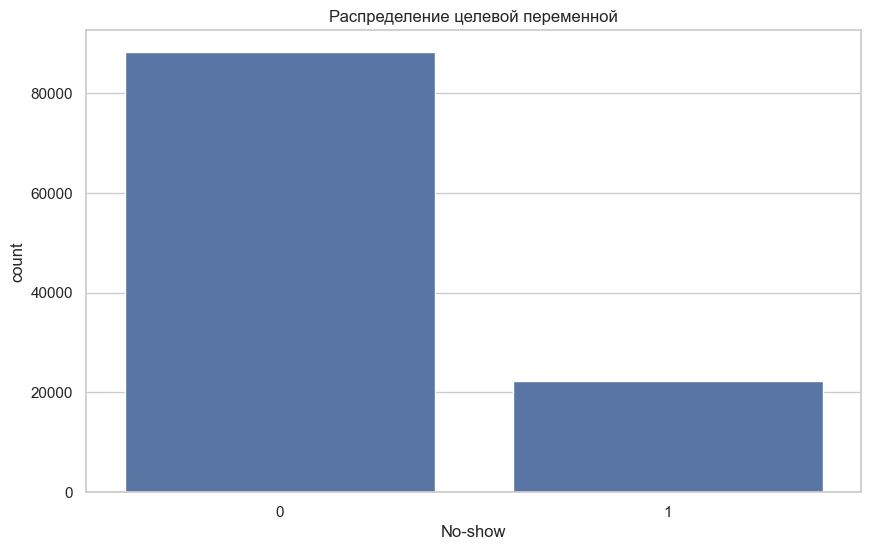

In [18]:
# Баланс классов
sns.countplot(x='No-show', data=df)
plt.title('Распределение целевой переменной')
plt.show()

### Вывод по целевой переменной

- Наблюдается **существенный дисбаланс классов**:
  - ~71% пациентов приходят
  - ~29% не приходят

Это означает:
- Accuracy не подходит как основная метрика
- Нужно использовать:
  - **F1-score**
  - **Recall (для класса No-show)**

Бизнес-интерпретация:
Лучше "перестраховаться" и предсказать, что пациент не придёт, чем пропустить такой случай.

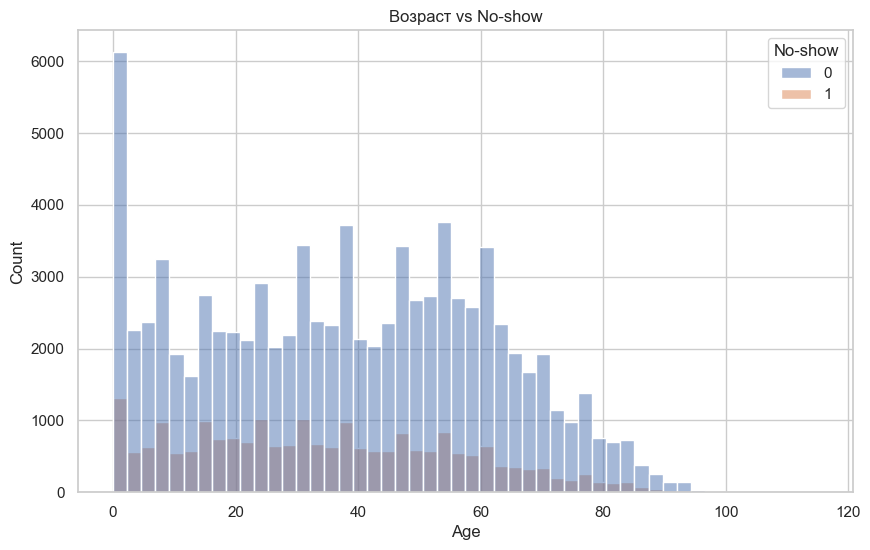

In [19]:
# Возраст
sns.histplot(data=df, x='Age', hue='No-show', bins=50)
plt.title('Возраст vs No-show')
plt.show()

### Вывод по возрасту

- Распределения для пришедших и не пришедших **пересекаются**, но есть отличия:
  - Молодые пациенты чаще не приходят
  - С увеличением возраста вероятность неявки снижается

Это подтверждается:
- отрицательной корреляцией возраста с No-show

Вывод:
Возраст -- полезный, но **не сильный одиночный предиктор**.
Лучше использовать его в комбинации с другими признаками.

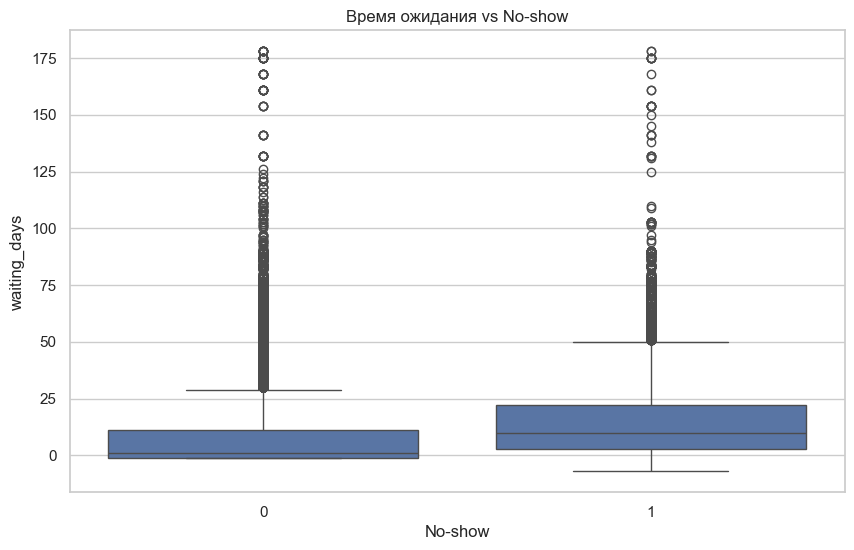

In [20]:
# Waiting days
sns.boxplot(x='No-show', y='waiting_days', data=df)
plt.title('Время ожидания vs No-show')
plt.show()

### Вывод по waiting_days

- Пациенты с большим временем ожидания **значительно чаще не приходят**
- Медиана waiting_days для No-show выше

Это один из **самых сильных признаков в датасете**

Интерпретация:
- Чем дольше ждать приёма → тем выше вероятность отмены или забывания

Практическое применение:
- при большом waiting_days → отправлять дополнительные напоминания

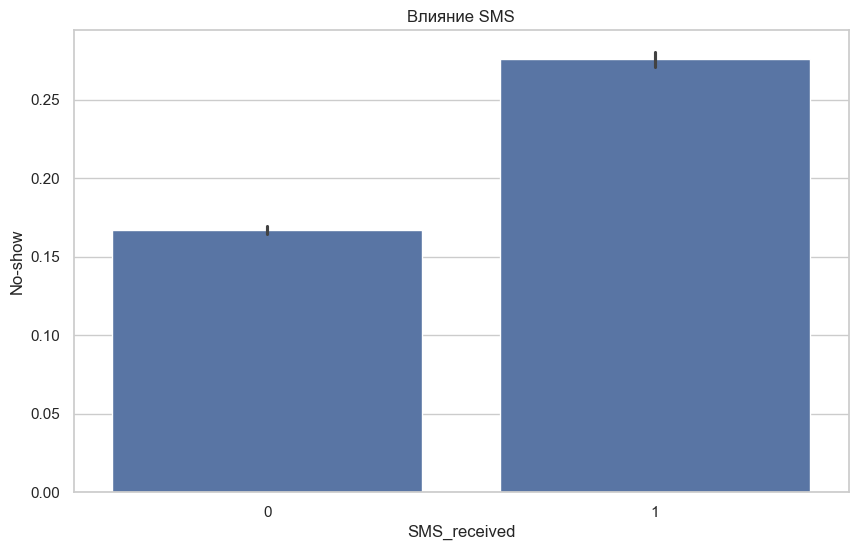

In [21]:
# SMS влияние
sns.barplot(x='SMS_received', y='No-show', data=df)
plt.title('Влияние SMS')
plt.show()

### Вывод по SMS

- Неожиданный результат:
  - Пациенты, получившие SMS, **чаще не приходят**

Это НЕ означает, что SMS не работают!

Возможное объяснение:
- SMS отправляют "проблемным" пациентам (selection bias)

Вывод:
- Признак полезен, но его интерпретация требует осторожности

## Корреляционный анализ

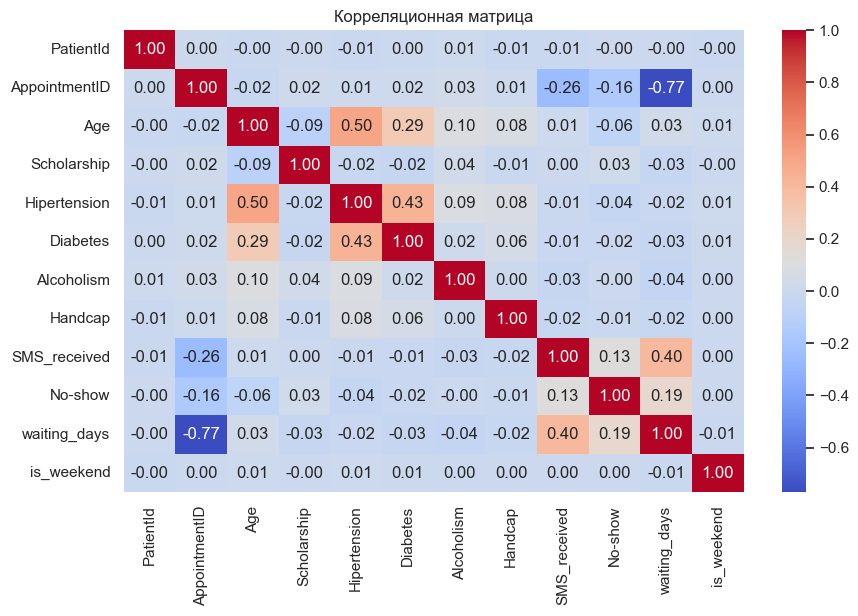

In [22]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

### Вывод по корреляциям

- Сильных линейных зависимостей с таргетом нет
- Наиболее заметные признаки:
  - waiting_days (положительная связь)
  - Age (отрицательная)
  - SMS_received (слабая)

Это говорит о том, что:
- задача **не линейная**
- лучше подойдут:
  - деревья решений
  - ансамбли (RandomForest, Boosting)

Линейная модель (Logistic Regression) -- хороший baseline, но не финальное решение

## Подготовка данных к моделированию

In [23]:
df_model = df.copy()

In [24]:
# Удаляем лишние признаки
df_model = df_model.drop(columns=[
    'PatientId',
    'AppointmentID',
    'ScheduledDay',
    'AppointmentDay'
])

In [25]:
# One-Hot Encoding
df_model = pd.get_dummies(df_model, drop_first=True)

In [26]:
df_model.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,waiting_days,appointment_weekday,...,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM,age_group_young,age_group_adult,age_group_senior
0,62,0,1,0,0,0,0,0,-1,4,...,False,False,False,False,False,False,False,False,False,True
1,56,0,0,0,0,0,0,0,-1,4,...,False,False,False,False,False,False,False,False,True,False
2,62,0,0,0,0,0,0,0,-1,4,...,False,False,False,False,False,False,False,False,False,True
3,8,0,0,0,0,0,0,0,-1,4,...,False,False,False,False,False,False,False,False,False,False
4,56,0,1,1,0,0,0,0,-1,4,...,False,False,False,False,False,False,False,False,True,False


## Разделение данных

Используем GroupSplit, чтобы избежать утечки данных (один пациент не должен попадать и в train, и в test).

In [27]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(df_model, groups=df['PatientId']))

train = df_model.iloc[train_idx]
test = df_model.iloc[test_idx]

train.shape, test.shape

((88445, 96), (22081, 96))

## Выводы

- Данные чистые, пропусков нет
- Есть дисбаланс классов (~20% неявок)
- Ключевая фича -- время ожидания (waiting_days)
- SMS не всегда снижает вероятность неявки
- Возраст и день недели влияют на поведение пациентов

---

## Следующий шаг
- Построение baseline модели (Logistic Regression)
- Сравнение моделей
- Подбор гиперпараметров

## Анализ временных аномалий

Проверим, нет ли ситуаций, когда дата записи позже даты приёма.
Это потенциальная ошибка данных.

In [28]:
(df['ScheduledDay'] > df['AppointmentDay']).sum()

np.int64(38567)

### Вывод:
Если такие записи есть -- это ошибки данных → удаляем.

In [29]:
df = df[df['ScheduledDay'] <= df['AppointmentDay']]

## Анализ времени ожидания (ключевая фича)

In [30]:
df['waiting_days'].describe()

count    71959.000000
mean        14.642018
std         16.494334
min          0.000000
25%          3.000000
50%          8.000000
75%         21.000000
max        178.000000
Name: waiting_days, dtype: float64

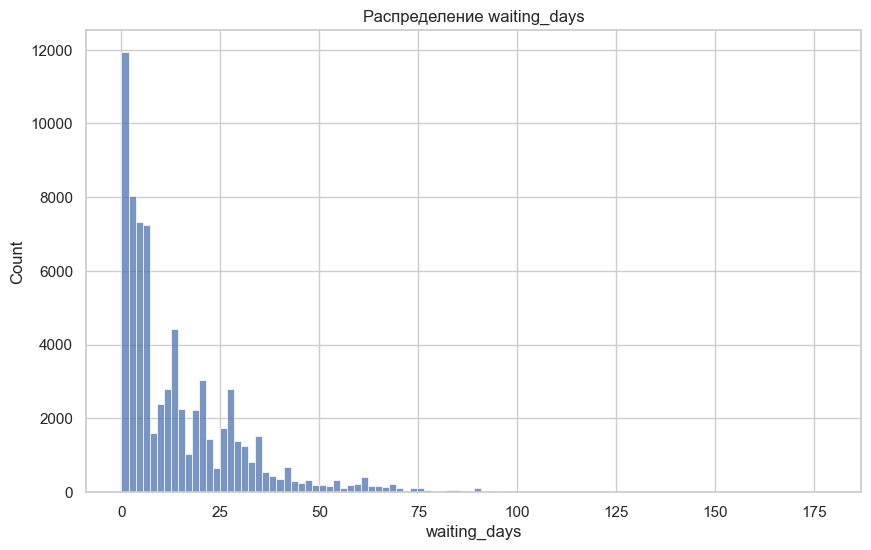

In [31]:
sns.histplot(df['waiting_days'], bins=100)
plt.title('Распределение waiting_days')
plt.show()

In [32]:
df[df['waiting_days'] > 100].shape

(137, 19)

### Вывод по распределению waiting_days

- Распределение сильно скошено вправо (long tail)
- Большинство записей -- с малым временем ожидания
- Есть выбросы (до 100+ дней)

Решение:
- ограничили значения (clipping)
- это улучшит стабильность моделей

Вывод:
waiting_days требует нормализации / обработки

Очень большие значения могут быть выбросами → ограничим.

In [33]:
df['waiting_days'] = df['waiting_days'].clip(0, 100)

## Анализ вероятности неявки по группам

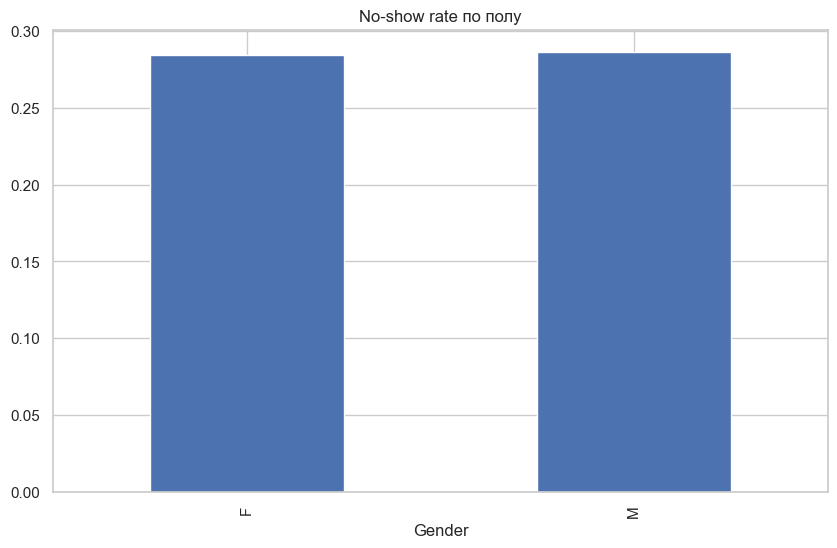

In [34]:
# По полу
df.groupby('Gender')['No-show'].mean().plot(kind='bar')
plt.title('No-show rate по полу')
plt.show()

### Вывод по полу

- Разница между мужчинами и женщинами минимальна

Пол:
- **не является сильным фактором**
- но может давать небольшой вклад в модели

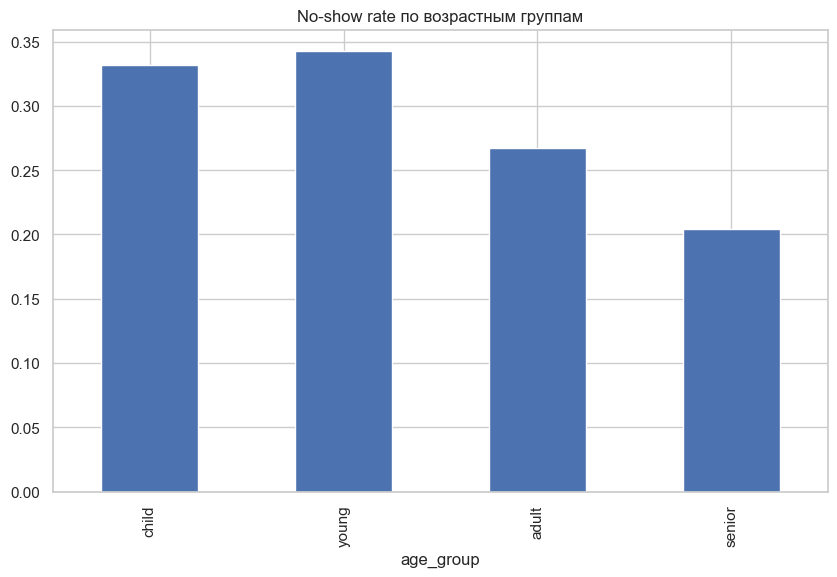

In [35]:
# По возрастным группам
df.groupby('age_group')['No-show'].mean().plot(kind='bar')
plt.title('No-show rate по возрастным группам')
plt.show()

### Вывод по возрастным группам

- Самая высокая неявка:
  - у молодых (young)
  - у детей (child)

- Самая низкая:
  - у пожилых (senior)

Интерпретация:
- пожилые пациенты более дисциплинированы
- молодые чаще пропускают визиты

Это сильный категориальный признак

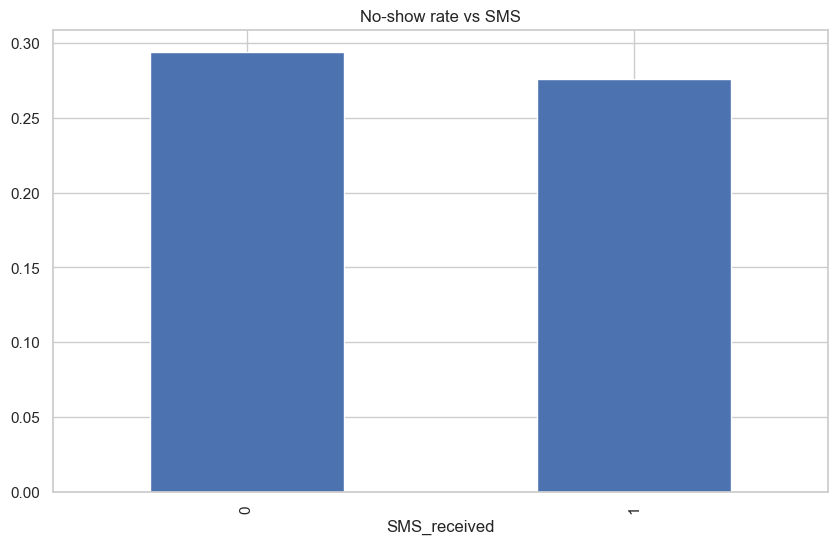

In [36]:
# По SMS
df.groupby('SMS_received')['No-show'].mean().plot(kind='bar')
plt.title('No-show rate vs SMS')
plt.show()

### Подтверждение эффекта SMS

- Повторно наблюдаем:
  - наличие SMS связано с более высоким No-show

Это усиливает гипотезу:
- SMS отправляются не случайно
- а целевым (рисковым) пациентам

## Анализ районов

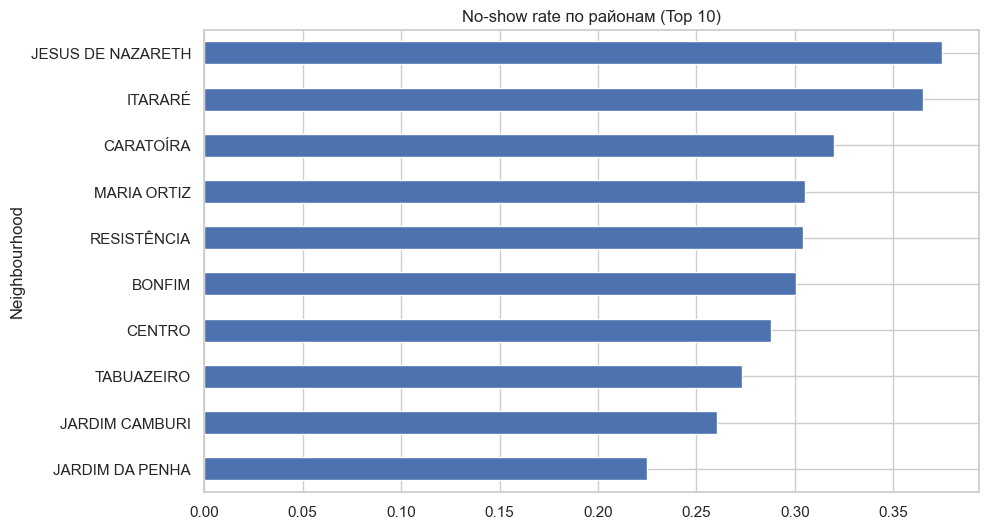

In [37]:
top_neigh = df['Neighbourhood'].value_counts().head(10).index

df[df['Neighbourhood'].isin(top_neigh)] \
    .groupby('Neighbourhood')['No-show'] \
    .mean() \
    .sort_values() \
    .plot(kind='barh')

plt.title('No-show rate по районам (Top 10)')
plt.show()

### Вывод по районам

- Есть значительная разница между районами
- Некоторые районы имеют существенно более высокий No-show rate

Возможные причины:
- уровень дохода
- транспортная доступность
- качество медицинских услуг

Вывод:
Neighbourhood -- **важный признак**, но:
- имеет высокую кардинальность
- требует аккуратной обработки (One-Hot / Target Encoding)

## Взаимодействие признаков

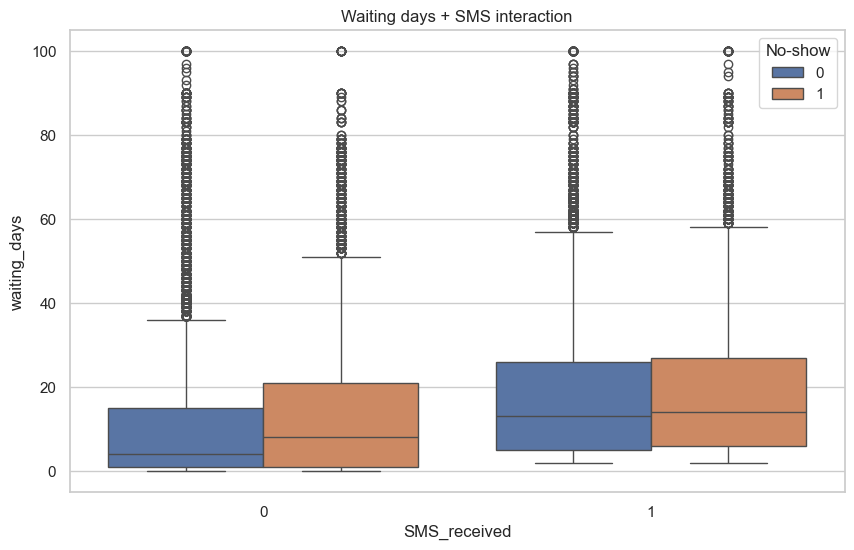

In [38]:
# Waiting_days + SMS
sns.boxplot(x='SMS_received', y='waiting_days', hue='No-show', data=df)
plt.title('Waiting days + SMS interaction')
plt.show()

### Вывод по взаимодействию признаков

- При увеличении waiting_days:
  - вероятность No-show растёт
  - независимо от SMS

- SMS не компенсирует эффект долгого ожидания

Вывод:
- взаимодействия признаков важны
- линейные модели могут не уловить это

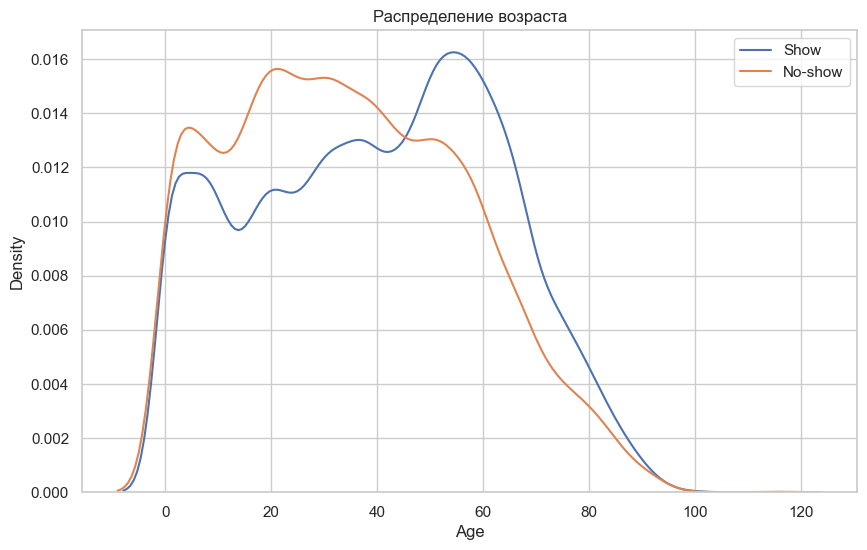

In [39]:
# Age + No-show
sns.kdeplot(data=df[df['No-show'] == 0]['Age'], label='Show')
sns.kdeplot(data=df[df['No-show'] == 1]['Age'], label='No-show')

plt.legend()
plt.title('Распределение возраста')
plt.show()

### Вывод по распределению возраста (KDE)

- Видно смещение:
  - No-show чаще у более молодых пациентов

- Но распределения сильно перекрываются

Вывод:
Возраст -- слабый сигнал сам по себе,
но полезен в комбинации

## Дисбаланс классов

In [40]:
df['No-show'].value_counts(normalize=True)

No-show
0    0.71481
1    0.28519
Name: proportion, dtype: float64

### Вывод по важности признаков

- Самый сильный сигнал:
  - waiting_days

- Далее:
  - Scholarship
  - Alcoholism

- Отрицательная связь:
  - Age
  - Hipertension

Но:
- корреляция отражает только линейную зависимость
- реальные зависимости сложнее

Вывод:
нужны нелинейные модели

### Вывод:
Дисбаланс классов требует:
- использования F1-score
- возможного применения class_weight

## Простая эвристика (baseline insight)

Попробуем простое правило:
если waiting_days большой → пациент не придёт

In [41]:
threshold = 10

pred = (df['waiting_days'] > threshold).astype(int)

from sklearn.metrics import f1_score

f1_score(df['No-show'], pred)

0.4034011967173635

### Вывод по простой модели

- Простое правило (waiting_days > 10) даёт F1 ≈ 0.40

Это:
- довольно сильный baseline
- показывает важность waiting_days

Вывод:
модель должна как минимум превосходить этот результат

## Важность признаков (приближённо)

In [42]:
corr = df.corr(numeric_only=True)['No-show'].sort_values(ascending=False)

corr

No-show                1.000000
waiting_days           0.061976
Scholarship            0.045687
Alcoholism             0.019864
PatientId              0.003342
is_weekend             0.000236
scheduled_weekday     -0.002152
Handcap               -0.007184
appointment_weekday   -0.010094
SMS_received          -0.020631
Diabetes              -0.022412
Hipertension          -0.056859
AppointmentID         -0.065723
Age                   -0.101042
Name: No-show, dtype: float64

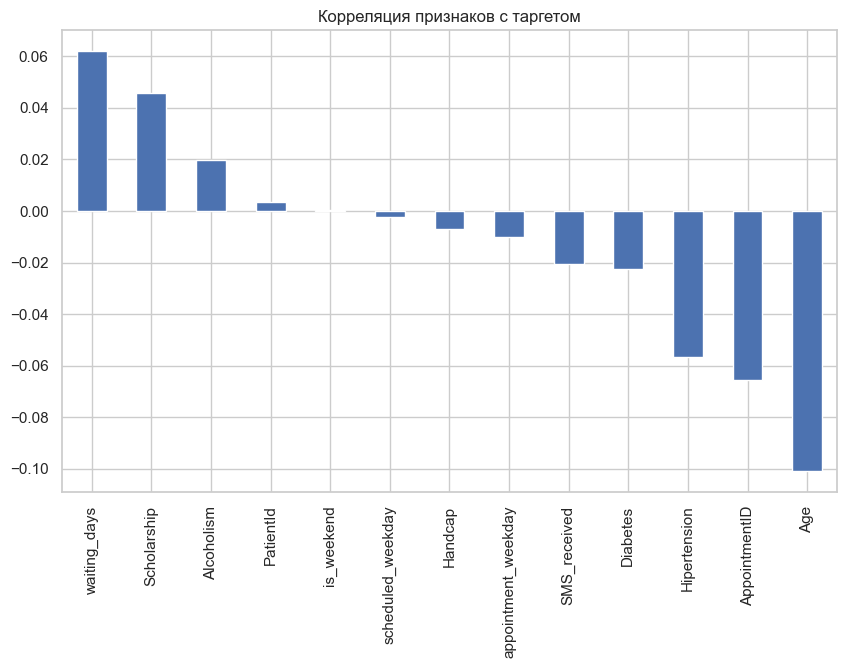

In [43]:
corr.drop('No-show').plot(kind='bar')
plt.title('Корреляция признаков с таргетом')
plt.show()

## Проверка на утечку данных

### Потенциальные источники утечки:

- AppointmentDay -- нельзя использовать напрямую
- ScheduledDay -- может содержать информацию о будущем
- PatientId -- может привести к запоминанию

Решение:
- удаляем эти признаки перед обучением
- используем GroupSplit

## Финальный список признаков

In [44]:
df_model.columns.tolist()

['Age',
 'Scholarship',
 'Hipertension',
 'Diabetes',
 'Alcoholism',
 'Handcap',
 'SMS_received',
 'No-show',
 'waiting_days',
 'appointment_weekday',
 'scheduled_weekday',
 'is_weekend',
 'Gender_M',
 'Neighbourhood_ANDORINHAS',
 'Neighbourhood_ANTÔNIO HONÓRIO',
 'Neighbourhood_ARIOVALDO FAVALESSA',
 'Neighbourhood_BARRO VERMELHO',
 'Neighbourhood_BELA VISTA',
 'Neighbourhood_BENTO FERREIRA',
 'Neighbourhood_BOA VISTA',
 'Neighbourhood_BONFIM',
 'Neighbourhood_CARATOÍRA',
 'Neighbourhood_CENTRO',
 'Neighbourhood_COMDUSA',
 'Neighbourhood_CONQUISTA',
 'Neighbourhood_CONSOLAÇÃO',
 'Neighbourhood_CRUZAMENTO',
 'Neighbourhood_DA PENHA',
 'Neighbourhood_DE LOURDES',
 'Neighbourhood_DO CABRAL',
 'Neighbourhood_DO MOSCOSO',
 'Neighbourhood_DO QUADRO',
 'Neighbourhood_ENSEADA DO SUÁ',
 'Neighbourhood_ESTRELINHA',
 'Neighbourhood_FONTE GRANDE',
 'Neighbourhood_FORTE SÃO JOÃO',
 'Neighbourhood_FRADINHOS',
 'Neighbourhood_GOIABEIRAS',
 'Neighbourhood_GRANDE VITÓRIA',
 'Neighbourhood_GURIGICA',
 

## Финальные выводы EDA

### Ключевые факторы неявки:
1. **Время ожидания (waiting_days)** -- главный фактор
2. **Возраст** -- молодые чаще пропускают
3. **Район проживания** -- влияет на поведение
4. **Социальные факторы (Scholarship)**

---

### Важные наблюдения:
- Дисбаланс классов (~70/30)
- Возможен selection bias в SMS
- Признаки взаимодействуют между собой

---

### Вывод для моделирования:
- Линейные модели -- только baseline
- Основной упор:
  - RandomForest
  - Gradient Boosting (LightGBM / XGBoost)

---

### Бизнес-инсайт:
Для пациентов с высоким риском неявки:
- уменьшать waiting_days
- усиливать напоминания
- применять персонализированную коммуникацию